<a href="https://colab.research.google.com/github/paolopi81/projectile-motion-simulator/blob/main/projectile_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Insert the initial rate of the velocity (m). v0 =30
Insert launch angle (deg). alpha =30
Insert the mass of the bullet (kg). m =0.1
Insert the coefficient of viscous friction (kg*s^-1). C= 0.2


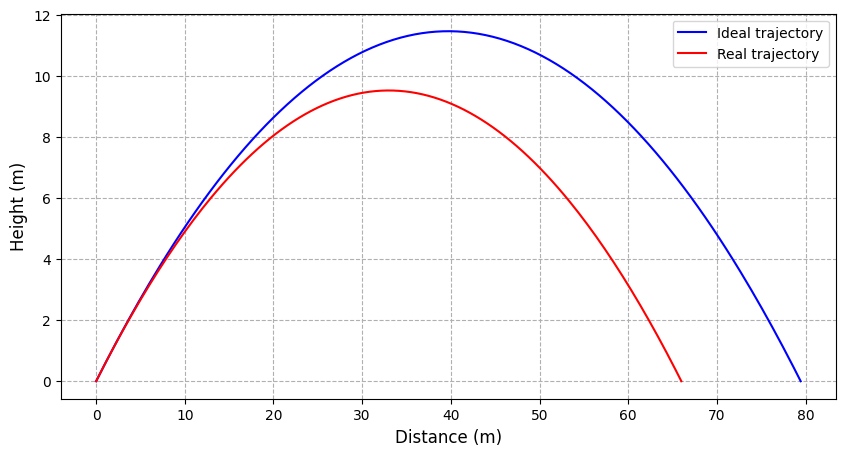

In [13]:
import numpy as np
import matplotlib.pyplot as plt

#DEFINING INITIAL CONDITIONS
g = 9.81 #m*s^-2
y0 = 0 #m
x0 = 0 #m

#TAKING USER INPUT
v0 = float(input("Insert the initial rate of the velocity (m). v0 ="))
alpha_deg = float(input("Insert launch angle (deg). alpha ="))
m = float(input("Insert the mass of the bullet (kg). m ="))
C = float(input("Insert the coefficient of viscous friction (kg*s^-1). C= "))

#CHECKING INPUTS
if alpha_deg == 90:
  print("Launch angle cannot be right")
else:
  alpha = alpha_deg*np.pi/180 #rad
  v0x = v0*np.cos(alpha)
  v0y = v0*np.sin(alpha)

#TRAJECTORY OF THE IDEAL BULLET
ideal_Range = (2*v0x*v0y)/g
def ideal_trajectory(x, g, alpha, v0x):
  ideal_second_term = (g*x**2) / (2 * v0x**2)
  return x * np.tan(alpha) - ideal_second_term

#TRAJECTORY OF THE REAL BULLET
real_second_term = ((g+C/m)) / (2 * v0x**2)
real_Range = np.tan(alpha)/real_second_term
def real_trajectory(u, g, alpha, v0x):
  return u * np.tan(alpha) - real_second_term*u**2

#CREATION OF THE COORDINATES
dx = np.linspace(0, ideal_Range, 200)
dy = ideal_trajectory(dx, g, alpha, v0x)
du = np.linspace(0, real_Range, 200)
dv = real_trajectory(du, g, alpha, v0x)

#PLOTTING
plt.figure(figsize=(10,5))
plt.plot(dx,dy, label="Ideal trajectory", color= "blue")
plt.plot(du, dv,label="Real trajectory", color= "red" )
plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Height (m)", fontsize=12)
plt.grid(True, linestyle='--')
plt.legend()
plt.show()
